In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import snorkel
from snorkel.labeling import labeling_function
from snorkel.labeling import labeling_function, PandasLFApplier
# Change the line below to this:
from snorkel.labeling.model import LabelModel

In [2]:
df_final_no_spend = pd.read_csv(
    "/Users/Thomas/Desktop/Master Thesis/Data/contract_final_no_spend.csv",
    dtype={
        "terminated": "str",
        "supplier_number": "str",
    },
)


In [3]:
df_stocks_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/stock_view.csv")

In [4]:
df_macro_index_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/macro_indexs.csv")

In [5]:
df_news = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/news.csv")

In [6]:
df_esg = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/esg_yearly.csv")

In [7]:
df_financials = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/financials_clean.csv")

# EDA for stocks

In [8]:
df_stocks_view.head()

,Unnamed: 0,BvD ID number,Company name Latin alphabet,Year,avg_vol,std_vol,max_vol,min_vol,vol_stability_score,vol_shock_ratio,...,Price_trends_52 weeks_%,market_beta_1y,Earnings_per_share_DKK,Book_value_per_share_DKK,Shares outstanding,Current_market_capitalisation_DKK,avg_closing_price,price_volatility_score,price_trend_slope,Risk level_stock_closing_price
0,0,AE0001327927,Rever Events L.L.C,2011,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
1,1,AE0001327927,Rever Events L.L.C,2012,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
2,2,AE0001327927,Rever Events L.L.C,2013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
3,3,AE0001327927,Rever Events L.L.C,2014,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
4,4,AE0001327927,Rever Events L.L.C,2015,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution


In [9]:
df_stocks_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 30288 entries, 0 to 30287
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         30288 non-null  int64  
 1   BvD ID number                      30288 non-null  str    
 2   Company name Latin alphabet        30288 non-null  str    
 3   Year                               30288 non-null  int64  
 4   avg_vol                            1064 non-null   float64
 5   std_vol                            1060 non-null   float64
 6   max_vol                            1064 non-null   float64
 7   min_vol                            1064 non-null   float64
 8   vol_stability_score                1059 non-null   float64
 9   vol_shock_ratio                    1064 non-null   float64
 10  vol_trend_slope                    1059 non-null   float64
 11  Join_Year                          30288 non-null  int64  
 12  R

In [10]:
def clean_eda_columns(df):
    # Columns that should be numeric but are marked as 'str' in your schema
    cols_to_convert = ['Shares outstanding', 'Current_market_capitalisation_DKK']
    
    for col in cols_to_convert:
        if col in df.columns:
            # Remove dots/commas and handle 'n.a.'
            df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_stocks_view = clean_eda_columns(df_stocks_view)

## Statistical Percentiles

In [11]:
key_signals = [
    'vol_shock_ratio', 'vol_trend_slope', 'market_cap_volatility', 
    'market_beta_1y', 'price_volatility_score', 'price_trend_slope'
]

# Generate detailed statistics
stats_summary = df_stocks_view[key_signals].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])
print("--- Snorkel Threshold Reference Table ---")
print(stats_summary)

--- Snorkel Threshold Reference Table ---
       vol_shock_ratio  vol_trend_slope  market_cap_volatility  \
count      1064.000000      1059.000000            1060.000000   
mean         39.280018         0.009956               0.129503   
std         769.483901         0.182040               0.088402   
min           0.000000        -1.879210               0.000000   
10%           1.714298        -0.047217               0.048644   
25%           2.117816        -0.016506               0.071901   
50%           2.945807         0.004407               0.109410   
75%           5.162125         0.026830               0.158267   
90%          10.205265         0.062724               0.236132   
95%          19.492026         0.131530               0.298709   
99%         244.404761         0.803195               0.479828   
max       24696.395897         2.000000               0.683626   

       market_beta_1y  price_volatility_score  price_trend_slope  
count     1392.000000           

## Distribution Plots

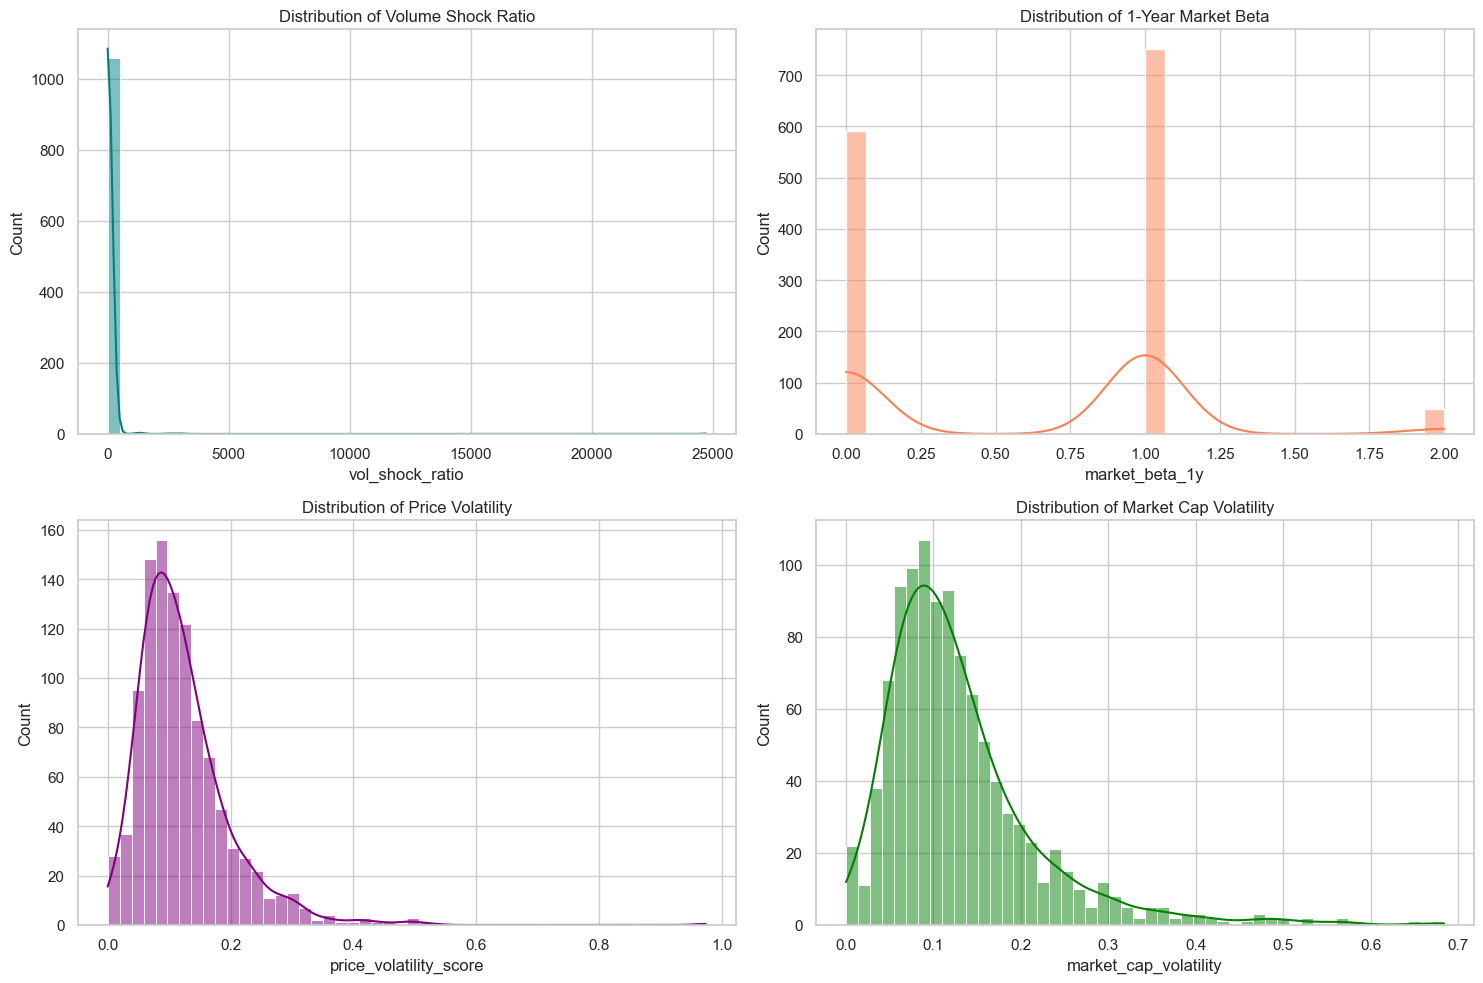

In [12]:
# Set visual style for a professional look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2)

# 1. Volume Shock (Sensitivity to events)
sns.histplot(df_stocks_view['vol_shock_ratio'].dropna(), bins=50, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Distribution of Volume Shock Ratio')

# 2. Market Beta (Systemic Risk)
sns.histplot(df_stocks_view['market_beta_1y'].dropna(), bins=30, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribution of 1-Year Market Beta')

# 3. Price Volatility (Market Sentiment)
sns.histplot(df_stocks_view['price_volatility_score'].dropna(), bins=50, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribution of Price Volatility')

# 4. Market Cap Volatility (Size Stability)
sns.histplot(df_stocks_view['market_cap_volatility'].dropna(), bins=50, kde=True, ax=axes[1,1], color='green')
axes[1,1].set_title('Distribution of Market Cap Volatility')

plt.tight_layout()
plt.show()

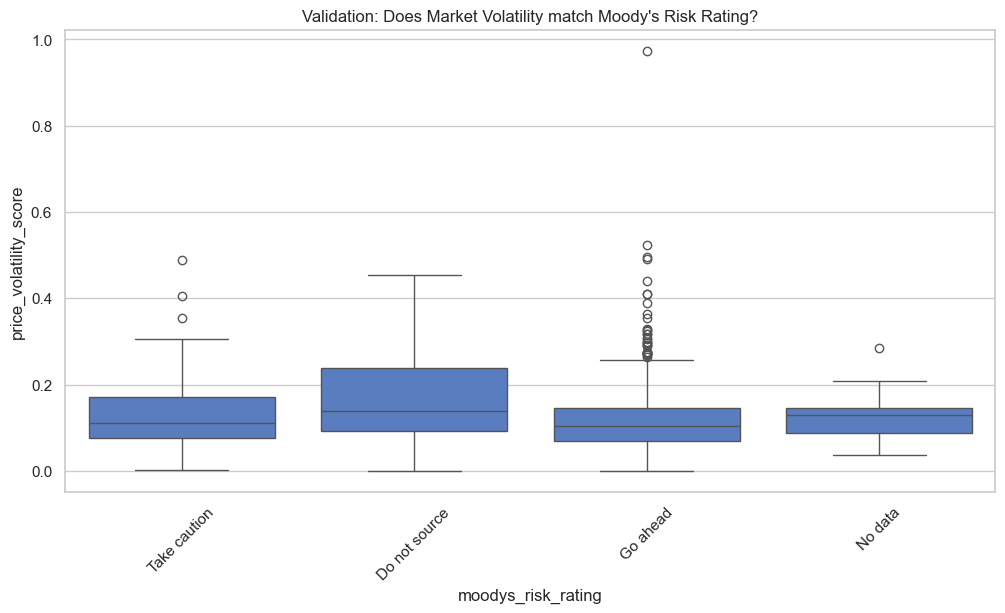

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_stocks_view, x='moodys_risk_rating', y='price_volatility_score')
plt.title('Validation: Does Market Volatility match Moody\'s Risk Rating?')
plt.xticks(rotation=45)
plt.show()

## Correlation heatmap

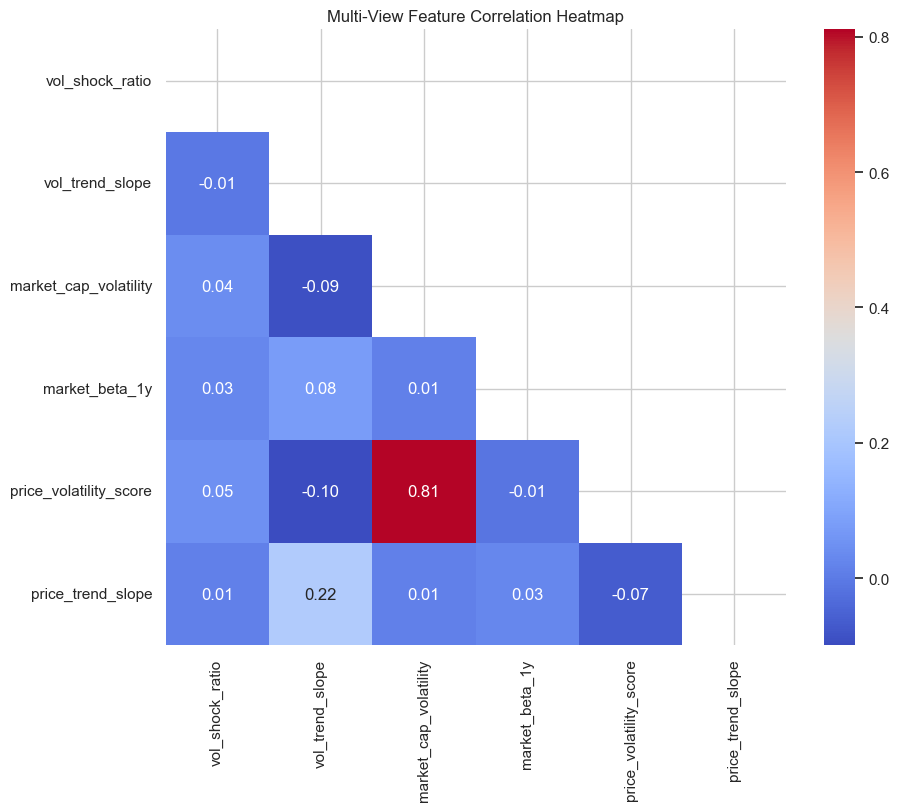

In [14]:
plt.figure(figsize=(10, 8))
corr = df_stocks_view[key_signals].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Only show bottom half
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f")
plt.title('Multi-View Feature Correlation Heatmap')
plt.show()

# EDA for macro indexes

In [15]:
df_macro_index_view.head()

,Unnamed: 0,Country,Code,LPI_Score,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,Year,PPI_Value
0,0,Afghanistan,AFG,1.211669,1.300000,1.100000,1.222220,1.250000,1.000000,1.375000,2007,NaN
1,1,Afghanistan,AFG,2.243160,2.223085,1.873596,2.244916,2.090449,2.365503,2.605503,2010,NaN
2,2,Afghanistan,AFG,2.297272,2.333617,2.003611,2.332182,2.162592,2.095155,2.795259,2012,NaN
3,3,Afghanistan,AFG,2.069573,2.163453,1.818951,1.986686,2.119709,1.847776,2.482138,2014,NaN
4,4,Afghanistan,AFG,1.948565,1.734900,1.807143,2.104431,1.919246,1.697024,2.382438,2018,NaN


In [16]:
df_macro_index_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1635 non-null   int64  
 1   Country                  1635 non-null   str    
 2   Code                     915 non-null    str    
 3   LPI_Score                1499 non-null   float64
 4   Customs                  1499 non-null   float64
 5   Infrastructure           1499 non-null   float64
 6   International_Shipments  1499 non-null   float64
 7   Logistics_Competence     1499 non-null   float64
 8   Tracking_Tracing         1499 non-null   float64
 9   Timeliness               1499 non-null   float64
 10  Year                     1635 non-null   int64  
 11  PPI_Value                945 non-null    float64
dtypes: float64(8), int64(2), str(2)
memory usage: 153.4 KB


## Statistical Thresholds

In [17]:
macro_cols = ['LPI_Score', 'Customs', 'Infrastructure', 'Logistics_Competence', 'PPI_Value']
stats_summary = df_macro_index_view[macro_cols].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95])

print("--- Macro Threshold Reference Table ---")
print(stats_summary)

--- Macro Threshold Reference Table ---
         LPI_Score      Customs  Infrastructure  Logistics_Competence  \
count  1499.000000  1499.000000     1499.000000           1499.000000   
mean      3.032795     2.835961        2.920345              2.995885   
std       0.611014     0.641267        0.734737              0.664998   
min       1.211669     1.300000        1.100000              1.250000   
5%        2.158762     1.941180        1.900000              2.072016   
10%       2.300000     2.083330        2.045943              2.184993   
25%       2.527419     2.334031        2.333331              2.454945   
50%       2.920566     2.695652        2.762986              2.870897   
75%       3.600000     3.395238        3.598421              3.600000   
90%       3.942263     3.800000        4.043594              3.966859   
95%       4.023764     3.917559        4.171078              4.100000   
max       4.300000     4.207790        4.600000              4.400000   

        PP

## Temporal Analysis

Text(0.5, 1.0, 'Global Macroeconomic Trends (2011-2026)')

<Figure size 1500x1000 with 0 Axes>

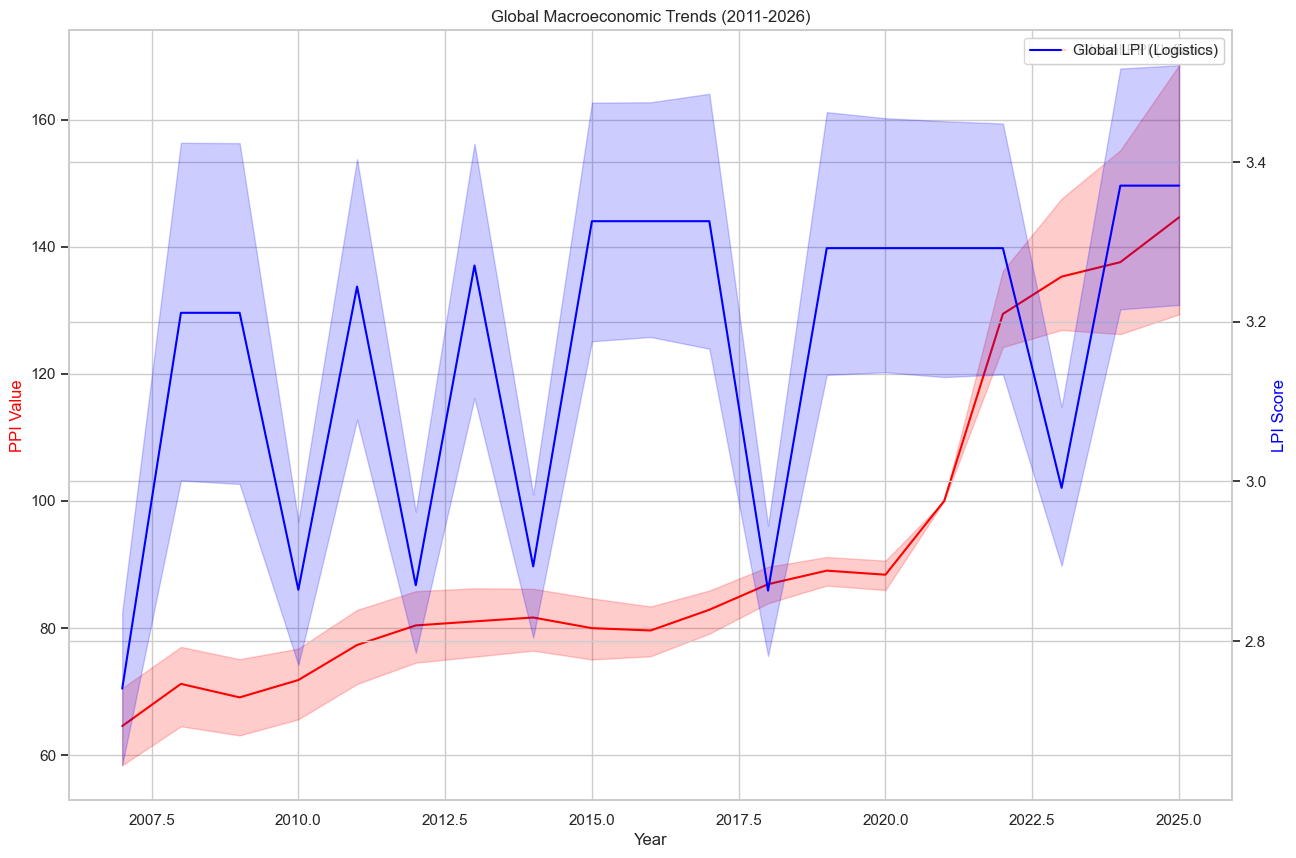

In [18]:
plt.figure()
# Plotting the global average PPI and LPI over time
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
sns.lineplot(data=df_macro_index_view, x='Year', y='PPI_Value', ax=ax1, color='red', label='Global PPI (Inflation)')
sns.lineplot(data=df_macro_index_view, x='Year', y='LPI_Score', ax=ax2, color='blue', label='Global LPI (Logistics)')

ax1.set_ylabel('PPI Value', color='red')
ax2.set_ylabel('LPI Score', color='blue')
plt.title('Global Macroeconomic Trends (2011-2026)')

## Correlation

Text(0.5, 1.0, 'Correlation between Logistics Dimensions')

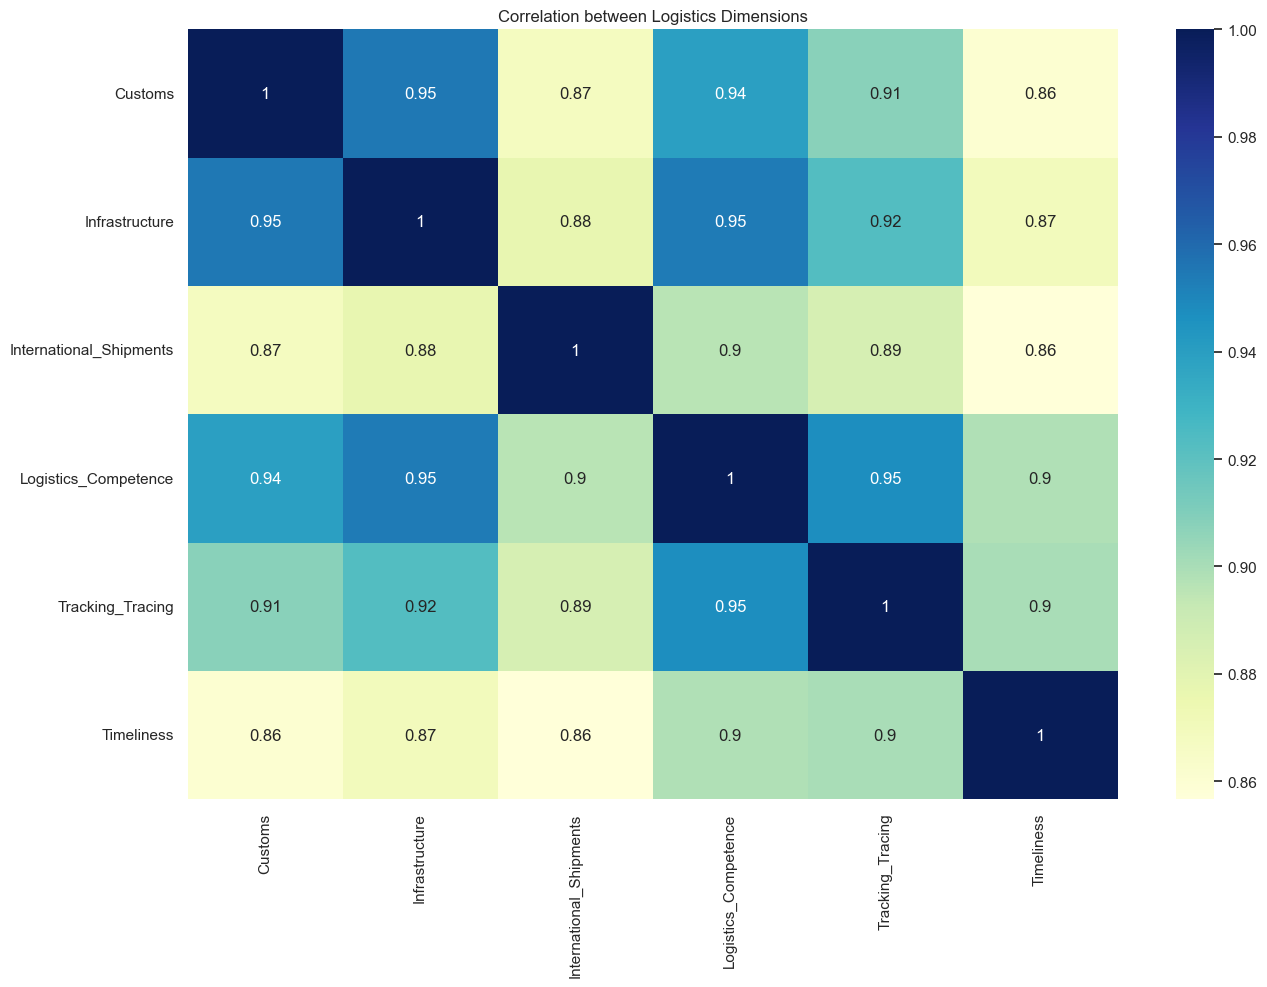

In [19]:
lpi_dimensions = ['Customs', 'Infrastructure', 'International_Shipments', 'Logistics_Competence', 'Tracking_Tracing', 'Timeliness']
plt.figure()
sns.heatmap(df_macro_index_view[lpi_dimensions].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation between Logistics Dimensions')

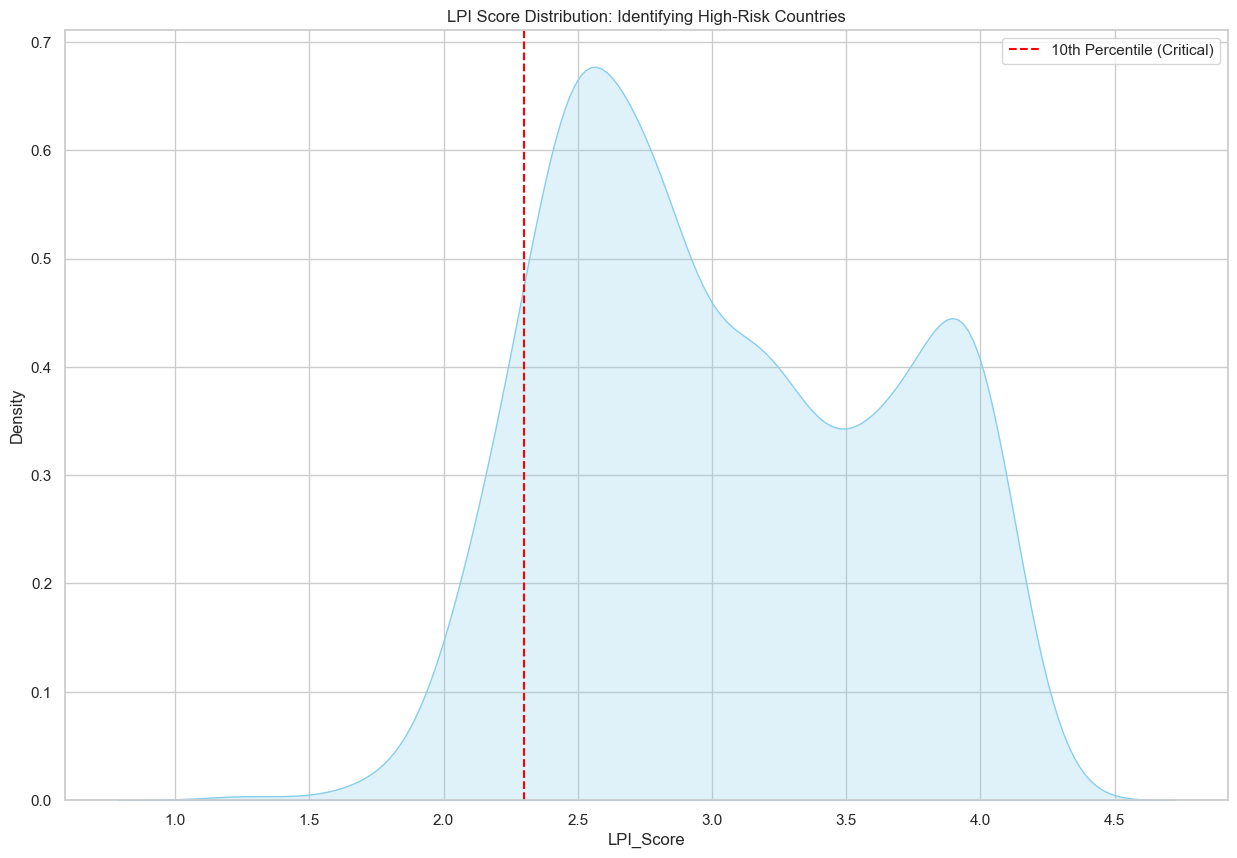

In [20]:
plt.figure()
sns.kdeplot(data=df_macro_index_view, x='LPI_Score', fill=True, color="skyblue")
plt.axvline(df_macro_index_view['LPI_Score'].quantile(0.10), color='red', linestyle='--', label='10th Percentile (Critical)')
plt.title('LPI Score Distribution: Identifying High-Risk Countries')
plt.legend()

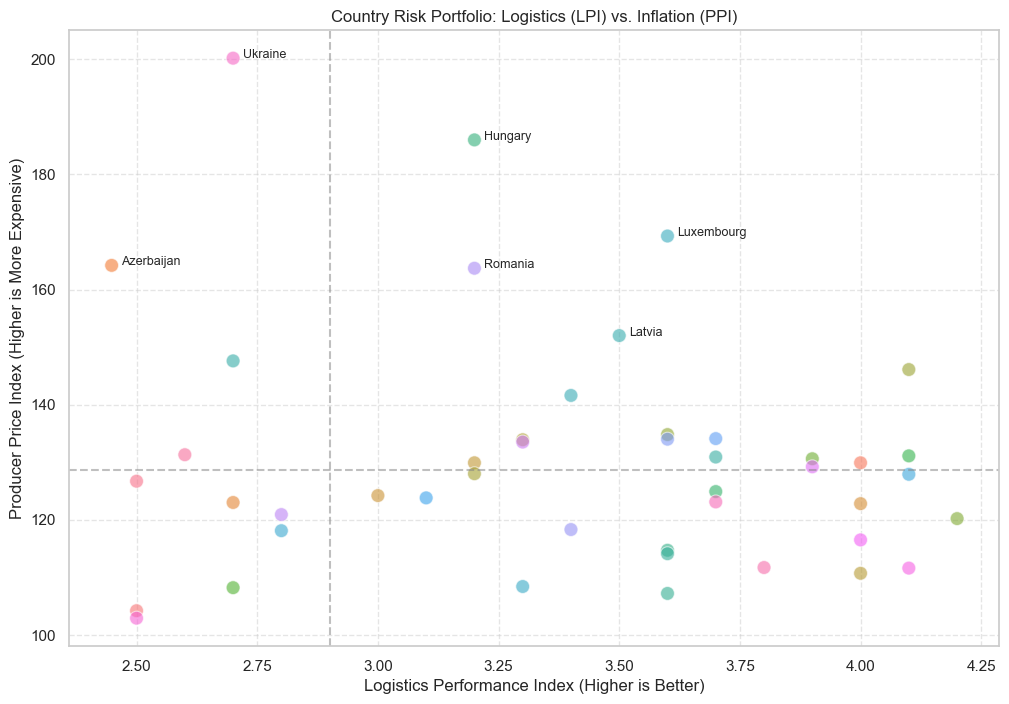

In [21]:


# We aggregate the macro data to get one bubble per country for the latest year (e.g., 2023)
# We assume 'Exposure' is the count of occurrences in your dataset for this example
df_plot = df_macro_index_view[df_macro_index_view['Year'] == 2023].copy()
df_plot['Exposure'] = df_plot.groupby('Country')['Country'].transform('count')

plt.figure(figsize=(12, 8))

# Create the bubble chart
bubble = sns.scatterplot(
    data=df_plot.dropna(subset=['LPI_Score', 'PPI_Value']),
    x='LPI_Score', 
    y='PPI_Value',
    size='Exposure',
    hue='Country',  # Or 'Region' if you have that column
    sizes=(100, 2000), # Adjust bubble size range
    alpha=0.6,
    legend=False
)

# Label the top risk countries manually for the thesis
for i in range(df_plot.shape[0]):
    # Label if LPI is very low or PPI is very high (The Red Zone)
    if df_plot.LPI_Score.iloc[i] < 2.5 or df_plot.PPI_Value.iloc[i] > 150:
        plt.text(
            df_plot.LPI_Score.iloc[i]+0.02, 
            df_plot.PPI_Value.iloc[i]+0.02, 
            df_plot.Country.iloc[i], 
            fontsize=9
        )

plt.title('Country Risk Portfolio: Logistics (LPI) vs. Inflation (PPI)')
plt.xlabel('Logistics Performance Index (Higher is Better)')
plt.ylabel('Producer Price Index (Higher is More Expensive)')
plt.grid(True, linestyle='--', alpha=0.5)

# Add quadrants
plt.axvline(x=df_plot['LPI_Score'].median(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=df_plot['PPI_Value'].median(), color='grey', linestyle='--', alpha=0.5)



# EDA for news data

In [22]:
print(df_news.shape)
print(df_news.info)

df_news.head()

(835, 11)
<bound method DataFrame.info of      supplier_number  Join_Year  article_count  negative_count  \
0            1011795       2017              1               0   
1            1011795       2019              2               0   
2            1011795       2020              3               0   
3            1011795       2022              8               0   
4            1011795       2023              8               0   
..               ...        ...            ...             ...   
830              998       2023             10               0   
831              998       2024             21               1   
832              998       2025             12               0   
833              998       2026              8               1   
834              998       2027             15               1   

     positive_count  neutral_count  avg_sentiment_score  avg_relevance_score  \
0                 1              0             1.000000             3.000000   
1    

,supplier_number,Join_Year,article_count,negative_count,positive_count,neutral_count,avg_sentiment_score,avg_relevance_score,max_relevance_score,negative_ratio,has_high_relevance_negative_news
0,1011795,2017,1,0,1,0,1.000,3.0000,3.0,0.0,0
1,1011795,2019,2,0,2,0,1.000,3.5000,4.0,0.0,0
2,1011795,2020,3,0,3,0,1.000,3.5000,4.0,0.0,0
3,1011795,2022,8,0,7,1,0.875,3.1875,4.0,0.0,0
4,1011795,2023,8,0,7,1,0.875,3.0625,3.5,0.0,0


Summary of key columns

In [23]:
cols = [
    "article_count",
    "negative_count",
    "avg_sentiment_score",
    "avg_relevance_score",
    "max_relevance_score",
    "negative_ratio",
    "has_high_relevance_negative_news"
]

display(df_news[cols].describe())

,article_count,negative_count,avg_sentiment_score,avg_relevance_score,max_relevance_score,negative_ratio,has_high_relevance_negative_news
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,5.883832,0.737725,0.560833,3.653618,3.960359,0.104233,0.185629
std,10.184611,2.566049,0.562061,0.575915,0.752882,0.254986,0.389040
min,1.000000,0.000000,-1.000000,3.000000,3.000000,0.000000,0.000000
25%,1.000000,0.000000,0.186147,3.000000,3.000000,0.000000,0.000000
50%,2.000000,0.000000,0.800000,3.500000,4.000000,0.000000,0.000000
75%,5.000000,0.000000,1.000000,4.000000,5.000000,0.000000,0.000000
max,96.000000,33.000000,1.000000,5.000000,5.000000,1.000000,1.000000


Coverage of simple candidate thresholds

In [24]:
threshold_summary = pd.DataFrame({
    "article_count >= 5": [df_news["article_count"].ge(5).mean()],
    "article_count >= 10": [df_news["article_count"].ge(10).mean()],
    "negative_count >= 1": [df_news["negative_count"].ge(1).mean()],
    "negative_count >= 2": [df_news["negative_count"].ge(2).mean()],
    "negative_ratio >= 0.10": [df_news["negative_ratio"].ge(0.10).mean()],
    "negative_ratio >= 0.20": [df_news["negative_ratio"].ge(0.20).mean()],
    "avg_sentiment_score <= 0.40": [df_news["avg_sentiment_score"].le(0.40).mean()],
    "has_high_relevance_negative_news = 1": [df_news["has_high_relevance_negative_news"].mean()],
}).T.reset_index()

threshold_summary.columns = ["candidate_rule", "share_of_rows"]
display(threshold_summary.sort_values("share_of_rows", ascending=False))

,candidate_rule,share_of_rows
0,article_count >= 5,0.306587
6,avg_sentiment_score <= 0.40,0.306587
2,negative_count >= 1,0.229940
4,negative_ratio >= 0.10,0.203593
7,has_high_relevance_negative_news = 1,0.185629
5,negative_ratio >= 0.20,0.156886
1,article_count >= 10,0.147305
3,negative_count >= 2,0.098204


Look at strongest negative-news cases

In [25]:
display(
    df_news.sort_values(
        ["negative_count", "negative_ratio", "max_relevance_score"],
        ascending=False
    )[
        [
            "supplier_number",
            "Join_Year",
            "article_count",
            "negative_count",
            "negative_ratio",
            "avg_sentiment_score",
            "avg_relevance_score",
            "max_relevance_score",
            "has_high_relevance_negative_news"
        ]
    ].head(20)
)

,supplier_number,Join_Year,article_count,negative_count,negative_ratio,avg_sentiment_score,avg_relevance_score,max_relevance_score,has_high_relevance_negative_news
711,48948,2027,46,33,0.717391,-0.543478,4.141304,5.0,1
713,48980,2027,64,21,0.328125,-0.078125,4.003125,5.0,1
111,1340608,2027,96,21,0.218750,0.312500,4.302083,5.0,1
338,19768,2027,61,20,0.327869,0.114754,4.240984,5.0,1
307,165500,2027,25,19,0.760000,-0.600000,4.840000,5.0,1
532,38224,2027,30,18,0.600000,-0.400000,3.906667,5.0,1
424,31179,2027,56,17,0.303571,0.178571,4.285714,5.0,1
171,14529,2025,18,14,0.777778,-0.777778,3.805556,4.5,1
278,162506,2026,61,14,0.229508,0.213115,3.955738,5.0,1
56,12440,2027,33,13,0.393939,-0.212121,3.921212,5.0,1


Simple plots

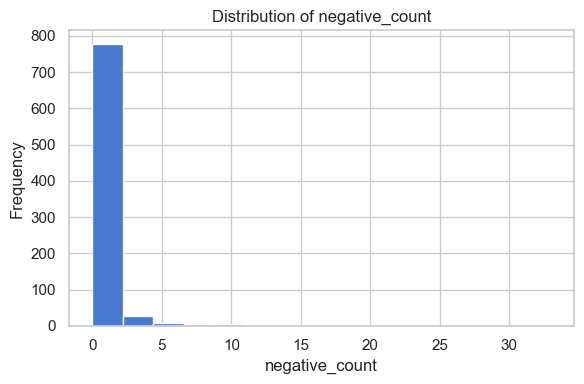

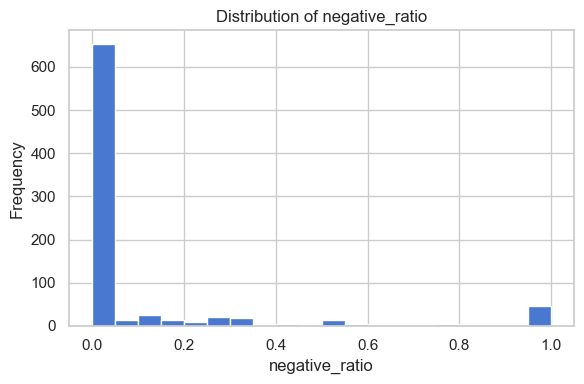

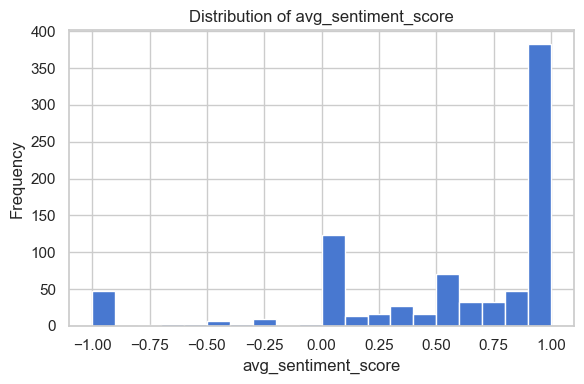

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df_news["negative_count"], bins=15)
plt.title("Distribution of negative_count")
plt.xlabel("negative_count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_news["negative_ratio"], bins=20)
plt.title("Distribution of negative_ratio")
plt.xlabel("negative_ratio")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_news["avg_sentiment_score"], bins=20)
plt.title("Distribution of avg_sentiment_score")
plt.xlabel("avg_sentiment_score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [27]:
# ------------------------------------------------------------
# 6. Optional: test a few exploratory rule flags
#    Not final labels, just EDA for justification
# ------------------------------------------------------------
df_news["rule_neg_volume"] = (
    (df_news["article_count"] >= 5) &
    (df_news["negative_count"] >= 2)
).astype(int)

df_news["rule_neg_ratio"] = (
    (df_news["article_count"] >= 5) &
    (df_news["negative_ratio"] >= 0.20)
).astype(int)

df_news["rule_high_rel_neg"] = (
    df_news["has_high_relevance_negative_news"] == 1
).astype(int)

df_news["rule_poor_sentiment"] = (
    (df_news["article_count"] >= 5) &
    (df_news["avg_sentiment_score"] <= 0.40)
).astype(int)

rule_summary = pd.DataFrame({
    "rule_neg_volume": [df_news["rule_neg_volume"].mean()],
    "rule_neg_ratio": [df_news["rule_neg_ratio"].mean()],
    "rule_high_rel_neg": [df_news["rule_high_rel_neg"].mean()],
    "rule_poor_sentiment": [df_news["rule_poor_sentiment"].mean()],
}).T.reset_index()

rule_summary.columns = ["rule", "share_of_rows"]
display(rule_summary.sort_values("share_of_rows", ascending=False))

,rule,share_of_rows
2,rule_high_rel_neg,0.185629
3,rule_poor_sentiment,0.086228
0,rule_neg_volume,0.082635
1,rule_neg_ratio,0.056287


# EDA for Financial data

In [28]:
df_financials.info()
df_financials.head()

<class 'pandas.DataFrame'>
RangeIndex: 3529 entries, 0 to 3528
Data columns (total 54 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   moodys_bvd_id                                    3529 non-null   str    
 1   moodys_company_name                              3529 non-null   str    
 2   Join_Year                                        3529 non-null   int64  
 3   closing_year                                     3529 non-null   float64
 4   closing_date                                     3529 non-null   str    
 5   created_at_utc                                   3529 non-null   str    
 6   Status                                           3529 non-null   str    
 7   Implied_rating                                   3514 non-null   str    
 8   risk_level                                       3517 non-null   str    
 9   Financial_level                          

,moodys_bvd_id,moodys_company_name,Join_Year,closing_year,closing_date,created_at_utc,Status,Implied_rating,risk_level,Financial_level,...,Long_term_liabilities_Equity_ratio,Short_term_liabilities_Equity_ratio,Interest_coverage_ratio,Solvency_ratio_Asset_based,Debt_Asset_ratio,ROE_using_Net_income,ROA_using_Net_income,Net_assets_turnover,Number_of_employees,financial_risk_score
0,GB02490104,Bio-Techne LTD,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,1.348341,29.784142,42.079646,76.259,0.195834,29.641,22.604,0.919,150.0,NaN
1,DE2110000553,Sartorius AG,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,A,Go ahead,Low financial risk,...,94.603031,67.825040,16.307692,38.106,0.359717,23.651,9.013,0.811,15942.0,1.0
2,LULB25789,SanisSure S.A.,2021,2021.0,2021-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Take caution,NaN,...,237.538807,34.619388,NaN,26.870,0.000000,NaN,NaN,NaN,NaN,NaN
3,DE7130049291,Amcor Flexibles Singen GmbH,2022,2022.0,2022-06-30,2026-03-05 09:02:26.421112+00:00,Active,Ba,Take caution,NaN,...,73.990382,309.642979,9.423212,20.677,0.000000,NaN,NaN,4.936,1242.0,NaN
4,LULB186284,Amazon Web Services EMEA SARL,2022,2022.0,2022-12-31,2026-03-05 09:02:26.421112+00:00,Active,Baa,Go ahead,Low financial risk,...,0.831076,235.324008,0.812609,29.748,0.000000,22.206,6.606,8.358,NaN,1.0


In [29]:
# Financial view screening
fin_cols = [
    "Implied_rating",
    "risk_level",
    "Financial_level",
    "financial_risk_score",
    "Current_ratio",
    "Gearing",
    "Long_term_Gearing",
    "Short_term_Gearing",
    "Debt_Asset_ratio",
    "Interest_coverage_ratio",
    "Solvency_ratio_Asset_based",
    "Long_term_liabilities_Equity_ratio",
    "Short_term_liabilities_Equity_ratio",
    "Profit_margin",
    "EBIT_margin",
    "ROE_using_Net_income",
    "ROA_using_Net_income",
]

screening = pd.DataFrame({
    "missing_pct": df_financials[fin_cols].isna().mean() * 100,
    "n_unique": df_financials[fin_cols].nunique()
}).sort_values("missing_pct")

display(screening)

,missing_pct,n_unique
risk_level,0.340040,4
Implied_rating,0.425050,9
Short_term_liabilities_Equity_ratio,12.808161,3038
Long_term_liabilities_Equity_ratio,12.836498,2639
Solvency_ratio_Asset_based,13.261547,2981
Current_ratio,14.083310,1993
Short_term_Gearing,16.803627,2156
ROA_using_Net_income,19.608954,2717
Gearing,20.855767,2570
ROE_using_Net_income,21.762539,2730


In [30]:
# Correlation only for numeric financial columns
numeric_fin_cols = [
    "financial_risk_score",
    "Current_ratio",
    "Gearing",
    "Long_term_Gearing",
    "Short_term_Gearing",
    "Debt_Asset_ratio",
    "Interest_coverage_ratio",
    "Solvency_ratio_Asset_based",
    "Long_term_liabilities_Equity_ratio",
    "Short_term_liabilities_Equity_ratio",
    "Profit_margin",
    "EBIT_margin",
    "ROE_using_Net_income",
    "ROA_using_Net_income",
]

corr = df_financials[numeric_fin_cols].corr().abs()

high_corr_pairs = (
    corr.where(~np.tril(np.ones(corr.shape)).astype(bool))
        .stack()
        .reset_index()
)
high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.90].sort_values("abs_corr", ascending=False)

display(high_corr_pairs)

,feature_1,feature_2,abs_corr
151,Profit_margin,EBIT_margin,0.92021


# EDA for ESG data

In [31]:
print(df_esg.shape)
print(df_esg.info())
df_esg.head()

(2093, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   moodys_bvd_id          2093 non-null   str    
 1   company_name           2093 non-null   str    
 2   risk_level             2093 non-null   str    
 3   sector                 2093 non-null   str    
 4   year                   2093 non-null   int64  
 5   Join_Year              2093 non-null   int64  
 6   esg_overall            2093 non-null   float64
 7   esg_industry_adjusted  2093 non-null   float64
 8   env_score              2093 non-null   float64
 9   env_weight             2093 non-null   float64
 10  social_score           2093 non-null   float64
 11  social_weight          2093 non-null   float64
 12  gov_score              2093 non-null   float64
 13  gov_weight             2093 non-null   float64
 14  industry_min           2093 non-null   float64
 15  indu

,moodys_bvd_id,company_name,risk_level,sector,year,Join_Year,esg_overall,esg_industry_adjusted,env_score,env_weight,social_score,social_weight,gov_score,gov_weight,industry_min,industry_max
0,AE0043368774,Fifth Element Event Management L.L.C,Take caution,Business Services,2023,2024,5.0,5.0,9.0,5.0,6.0,28.0,5.0,67.0,3.0,8.0
1,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2023,2024,3.0,1.0,3.0,33.0,3.0,20.0,5.0,47.0,3.0,7.0
2,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2024,2025,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
3,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2025,2026,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
4,AT9110192427,Flextronics International Gesellschaft m.b.H.,Do not source,Metals & Metal Products,2023,2024,4.0,1.0,4.0,40.0,4.0,25.0,5.0,35.0,4.0,7.0


In [32]:
df_esg["esg_position_in_industry_range"] = (
    (df_esg["esg_overall"] - df_esg["industry_min"]) /
    (df_esg["industry_max"] - df_esg["industry_min"])
)

print("\nSummary of ESG position in industry range:")
display(df_esg["esg_position_in_industry_range"].describe())


Summary of ESG position in industry range:


count    2093.000000
mean        0.412765
std         0.250206
min        -0.333333
25%         0.250000
50%         0.400000
75%         0.500000
max         1.333333
Name: esg_position_in_industry_range, dtype: float64

Quick threshold checks for possible labeling logic

In [33]:
threshold_summary = pd.DataFrame({
    "esg_overall <= 2": [df_esg["esg_overall"].le(2).mean()],
    "esg_overall <= 3": [df_esg["esg_overall"].le(3).mean()],
    "esg_industry_adjusted <= 1": [df_esg["esg_industry_adjusted"].le(1).mean()],
    "esg_industry_adjusted <= 2": [df_esg["esg_industry_adjusted"].le(2).mean()],
    "env_score <= 2": [df_esg["env_score"].le(2).mean()],
    "env_score <= 3": [df_esg["env_score"].le(3).mean()],
    "social_score <= 2": [df_esg["social_score"].le(2).mean()],
    "social_score <= 3": [df_esg["social_score"].le(3).mean()],
    "gov_score <= 4": [df_esg["gov_score"].le(4).mean()],
    "position_in_range <= 0.10": [df_esg["esg_position_in_industry_range"].le(0.10).mean()],
    "position_in_range <= 0.25": [df_esg["esg_position_in_industry_range"].le(0.25).mean()],
}).T.reset_index()

threshold_summary.columns = ["candidate_rule", "share_of_rows"]
display(threshold_summary.sort_values("share_of_rows", ascending=False))

,candidate_rule,share_of_rows
7,social_score <= 3,0.456283
10,position_in_range <= 0.25,0.362637
5,env_score <= 3,0.304826
6,social_score <= 2,0.296226
3,esg_industry_adjusted <= 2,0.273292
4,env_score <= 2,0.182513
1,esg_overall <= 3,0.175346
2,esg_industry_adjusted <= 1,0.154802
9,position_in_range <= 0.10,0.113235
8,gov_score <= 4,0.053034


In [34]:
display(
    df_esg[
        [
            "company_name",
            "Join_Year",
            "risk_level",
            "sector",
            "esg_overall",
            "esg_industry_adjusted",
            "env_score",
            "social_score",
            "gov_score",
            "industry_min",
            "industry_max",
            "esg_position_in_industry_range"
        ]
    ]
    .sort_values(
        ["esg_overall", "esg_industry_adjusted", "esg_position_in_industry_range"],
        ascending=True
    )
    .head(20)
)

,company_name,Join_Year,risk_level,sector,esg_overall,esg_industry_adjusted,env_score,social_score,gov_score,industry_min,industry_max,esg_position_in_industry_range
442,"Wuxi biologics co., ltd.",2024,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
469,"Beijing doublerise technology co., ltd.",2024,Take caution,Retail,2.0,0.0,3.0,0.0,4.0,3.0,6.0,-0.333333
470,"Beijing doublerise technology co., ltd.",2025,Take caution,Retail,2.0,0.0,4.0,0.0,4.0,3.0,6.0,-0.333333
471,"Beijing doublerise technology co., ltd.",2023,Take caution,Retail,2.0,0.0,3.0,0.0,4.0,3.0,6.0,-0.333333
502,"Nanjing gensript biotechnology co., ltd.",2024,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
503,"Nanjing gensript biotechnology co., ltd.",2023,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
1001,Evapharma FOR Pharmaceutical Industries,2024,Do not source,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,2.0,4.0,2.0,6.0,0.000000
1002,Evapharma FOR Pharmaceutical Industries,2025,Do not source,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,0.0,1.0,4.0,2.0,6.0,0.000000
1485,"Korea Engineering Plastics Co.,Ltd",2025,Go ahead,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,0.0,4.0,2.0,6.0,0.000000
73,Sopharma AD,2024,Go ahead,"Chemicals, Petroleum, Rubber & Plastic",2.0,1.0,2.0,2.0,3.0,2.0,6.0,0.000000


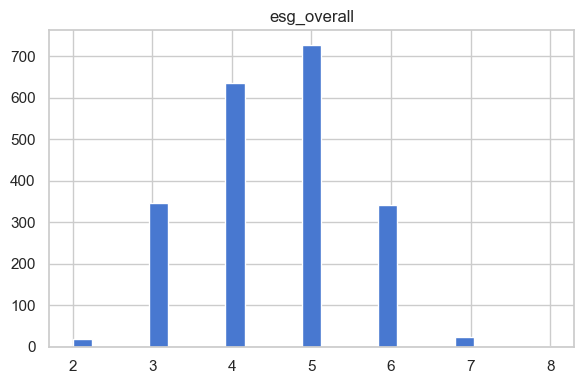

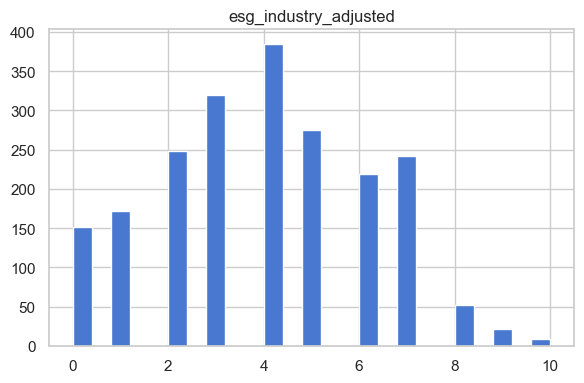

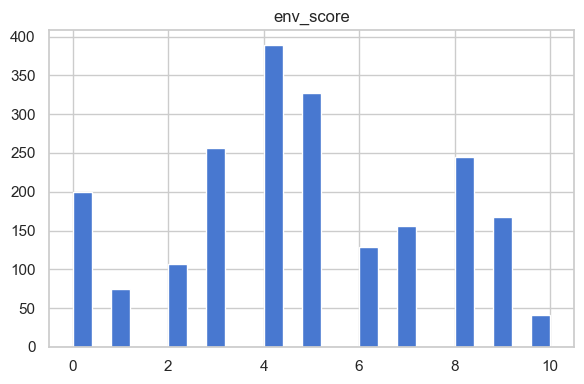

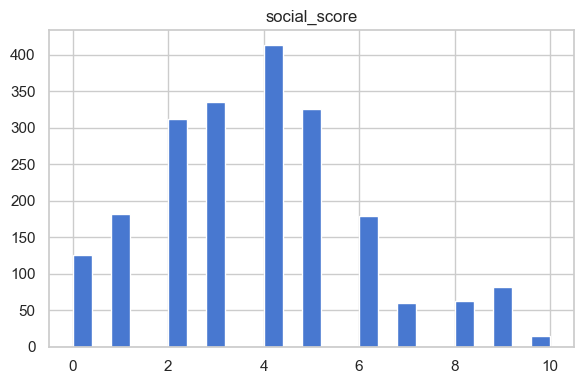

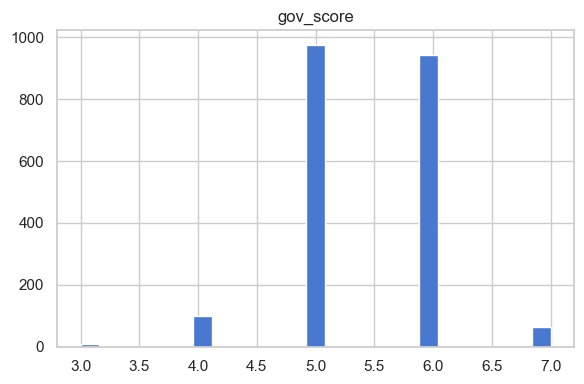

In [35]:
# ------------------------------------------------------------
# 5. Simple plots
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(df_esg["esg_overall"], bins=25)
plt.title("esg_overall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["esg_industry_adjusted"], bins=25)
plt.title("esg_industry_adjusted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["env_score"], bins=25)
plt.title("env_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["social_score"], bins=25)
plt.title("social_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["gov_score"], bins=25)
plt.title("gov_score")
plt.tight_layout()
plt.show()

# Feature engineering

In [36]:
df_features = df_final_no_spend.copy()

In [37]:
print(df_features.shape)
print(df_features.columns.tolist())

(9201, 149)
['Unnamed: 0', 'contract_id', 'contract_number', 'contract_name', 'contract_status', 'contract_owner_cost_centre', 'terminated', 'term_type', 'start_date', 'expiration_date', 'supplier_id', 'supplier_number', 'supplier_display_name', 'payment_terms', 'incoterms', 'contract_currency_code', 'contract_value', 'contract_value_dkk', 'contract_type', 'nn_contract_type', 'contract_commodity', 'team', 'unit', 'company_country', 'days_until_expiry', 'expiry_range', 'Preferred_supplier_tag', 'start_year', 'expiry_year', 'open_ended_contract', 'end_year', 'start_year_capped', 'observation_year', 'years_to_expiry', 'contract_age_years', 'expiry_pressure_bucket', 'department_from_cost_center', 'department', 'moodys_bvd_id', 'fin_moodys_company_name', 'fin_closing_year', 'fin_closing_date', 'fin_created_at_utc', 'fin_Status', 'fin_Implied_rating', 'fin_risk_level', 'fin_Financial_level', 'fin_output_text', 'fin_Implied_rating - original', 'fin_Number_of_months', 'fin_Net_Salesth_DKK', 'f

In [38]:
df_contracts_per_department = (
    df_features
    .groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contract_count")
    .sort_values("unique_contract_count", ascending=False)
)

print(df_contracts_per_department)

                                 department  unique_contract_count
3                         Devices & Needles                    476
5                  Drug Product Outsourcing                    300
6                Drug Substance Outsourcing                    298
10                       Packaging Material                    289
13                   Raw Materials & Energy                    281
12  Quality, Production Services & Supplies                    215
1             Bioprocessing & Raw Materials                    113
9                                 Logistics                     95
2              Bioprocessing and Excipients                     59
0          Alliance, Acquisitions & PPM CoE                     35
11           Purchasing Excellence External                     20
14                Strategic Sourcing US Hub                      9
7    Global Strategic Outsourcing & Devices                      8
8            HI Warehouse Expansion Program                   

## Financial Features

Helper functions

In [39]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Safely divide two Series and return NaN where denominator is 0 or missing."""
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def make_missing_flag(df: pd.DataFrame, col: str, flag_name: str | None = None) -> pd.DataFrame:
    """Create a missingness flag for a column."""
    if flag_name is None:
        flag_name = f"{col}_missing_flag"
    df[flag_name] = df[col].isna().astype(int)
    return df


Standardize columns

In [40]:
financial_column_map = {
    "fin_Implied_rating": "fin_implied_rating",
    "fin_risk_level": "fin_risk_level",
    "fin_Financial_level": "fin_financial_level",
    "fin_financial_risk_score": "fin_financial_risk_score",
    "fin_Current_ratio": "fin_current_ratio",
    "fin_Gearing": "fin_gearing",
    "fin_Long_term_Gearing": "fin_long_term_gearing",
    "fin_Short_term_Gearing": "fin_short_term_gearing",
    "fin_Debt_Asset_ratio": "fin_debt_asset_ratio",
    "fin_Interest_coverage_ratio": "fin_interest_coverage_ratio",
    "fin_Solvency_ratio_Asset_based": "fin_solvency_ratio_asset_based",
    "fin_Long_term_liabilities_Equity_ratio": "fin_long_term_liabilities_equity_ratio",
    "fin_Short_term_liabilities_Equity_ratio": "fin_short_term_liabilities_equity_ratio",
    "fin_Profit_margin": "fin_profit_margin",
    "fin_EBIT_margin": "fin_ebit_margin",
    "fin_ROE_using_Net_income": "fin_roe_net_income",
    "fin_ROA_using_Net_income": "fin_roa_net_income",
}

for old_col, new_col in financial_column_map.items():
    if old_col in df_features.columns and new_col not in df_features.columns:
        df_features = df_features.rename(columns={old_col: new_col})

Insure numerical values 

In [41]:
numeric_fin_cols = [
    "fin_financial_risk_score",
    "fin_current_ratio",
    "fin_gearing",
    "fin_long_term_gearing",
    "fin_short_term_gearing",
    "fin_debt_asset_ratio",
    "fin_interest_coverage_ratio",
    "fin_solvency_ratio_asset_based",
    "fin_long_term_liabilities_equity_ratio",
    "fin_short_term_liabilities_equity_ratio",
    "fin_profit_margin",
    "fin_ebit_margin",
    "fin_roe_net_income",
    "fin_roa_net_income",
]

for col in numeric_fin_cols:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

Missing flags

In [42]:
missing_flag_cols = [
    "fin_implied_rating",
    "fin_risk_level",
    "fin_financial_level",
    "fin_financial_risk_score",
    "fin_current_ratio",
    "fin_gearing",
    "fin_short_term_gearing",
    "fin_long_term_gearing",
    "fin_interest_coverage_ratio",
    "fin_profit_margin",
    "fin_ebit_margin",
]

for col in missing_flag_cols:
    if col in df_features.columns:
        df_features = make_missing_flag(df_features, col, f"{col}_missing_flag")

### Rating / summarized risk features

The first group of financial features captures **high-level external or summarized risk assessments**. These variables are useful because they compress complex financial information into interpretable risk categories that can be translated into weak labeling rules.

In this project, the most important variables in this category are:

- `fin_implied_rating`
- `fin_risk_level`
- `fin_financial_level`
- `fin_financial_risk_score`

In [43]:
if "fin_implied_rating" in df_features.columns:
    rating_order = {
        "Aaa": 1,
        "Aa": 2,
        "A": 3,
        "Baa": 4,
        "Ba": 5,
        "B": 6,
        "Caa": 7,
        "Ca": 8,
        "C": 9,
    }
    df_features["fin_implied_rating_ordinal"] = df_features["fin_implied_rating"].map(rating_order)

    df_features["fin_flag_weak_implied_rating"] = (
        df_features["fin_implied_rating"].isin(["Ba", "B", "Caa", "Ca", "C"])
    ).astype(int)

    df_features["fin_flag_moderate_or_worse_rating"] = (
        df_features["fin_implied_rating"].isin(["Baa", "Ba", "B", "Caa", "Ca", "C"])
    ).astype(int)

if "fin_risk_level" in df_features.columns:
    df_features["fin_flag_risk_take_caution_or_worse"] = (
        df_features["fin_risk_level"].isin(["Take caution", "Do not source"])
    ).astype(int)

    df_features["fin_flag_risk_do_not_source"] = (
        df_features["fin_risk_level"].eq("Do not source")
    ).astype(int)

if "fin_financial_level" in df_features.columns:
    df_features["fin_flag_high_financial_risk_level"] = (
        df_features["fin_financial_level"].isin(["High financial risk", "Very high financial risk"])
    ).astype(int)

if "fin_financial_risk_score" in df_features.columns:
    df_features["fin_flag_financial_risk_score_high"] = (
        df_features["fin_financial_risk_score"] >= 3
    ).astype(int)

    df_features["fin_flag_financial_risk_score_very_high"] = (
        df_features["fin_financial_risk_score"] >= 4
    ).astype(int)

### Liquidity stress features

Liquidity stress reflects whether a supplier can meet its short-term obligations. A standard and widely used liquidity measure is the **current ratio**, defined as:


$\text{Current Ratio} = \frac{\text{Current Assets}}{\text{Current Liabilities}}$




The current ratio measures a firm's ability to cover short-term obligations with short-term assets. Lower values indicate weaker liquidity and potentially higher short-term financial pressure.  [oai_citation:1‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/accounting/current-ratio-formula/?utm_source=chatgpt.com)

In the feature engineering step, the raw current ratio is kept, but it is also converted into interpretable stress flags such as:

- `fin_flag_liquidity_stress`
- `fin_flag_severe_liquidity_stress`
- `fin_flag_strong_liquidity`

In [44]:
if "fin_current_ratio" in df_features.columns:
    df_features["fin_flag_liquidity_stress"] = (
        df_features["fin_current_ratio"] < 1
    ).astype(int)

    df_features["fin_flag_severe_liquidity_stress"] = (
        df_features["fin_current_ratio"] < 0.75
    ).astype(int)

    df_features["fin_flag_strong_liquidity"] = (
        df_features["fin_current_ratio"] >= 2
    ).astype(int)

### Leverage / liability stress features

Leverage features aim to capture whether a supplier is under pressure from debt and liabilities relative to equity or assets. This is relevant because highly leveraged firms may be more exposed to refinancing pressure, reduced flexibility, or short-term commercial sensitivity.

A common leverage ratio is the debt-to-equity ratio (also described as gearing), typically expressed as:


$\text{Debt-to-Equity Ratio} = \frac{\text{Total Debt}}{\text{Shareholders' Equity}}$


A related solvency-oriented ratio is the debt-to-asset ratio:


$\text{Debt-to-Asset Ratio} = \frac{\text{Total Debt}}{\text{Total Assets}}$


These ratios are standard measures of leverage and financial burden. Higher values indicate greater reliance on debt financing and potentially greater financial pressure.  [oai_citation:2‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/debt-to-equity-ratio-formula/?utm_source=chatgpt.com)

In this project, leverage is represented through features such as:

- `fin_gearing`
- `fin_long_term_gearing`
- `fin_short_term_gearing`
- `fin_debt_asset_ratio`
- `fin_long_term_liabilities_equity_ratio`
- `fin_short_term_liabilities_equity_ratio`

These are engineered into stress indicators such as:

- high gearing
- high short-term gearing
- high debt-to-asset burden
- high liabilities-to-equity burden

In [45]:
if "fin_gearing" in df_features.columns:
    df_features["fin_flag_gearing_high"] = (
        df_features["fin_gearing"] > 100
    ).astype(int)

if "fin_long_term_gearing" in df_features.columns:
    df_features["fin_flag_long_term_gearing_high"] = (
        df_features["fin_long_term_gearing"] > 100
    ).astype(int)

if "fin_short_term_gearing" in df_features.columns:
    df_features["fin_flag_short_term_gearing_high"] = (
        df_features["fin_short_term_gearing"] > 100
    ).astype(int)

if "fin_debt_asset_ratio" in df_features.columns:
    df_features["fin_flag_debt_asset_high"] = (
        df_features["fin_debt_asset_ratio"] > 0.70
    ).astype(int)

    df_features["fin_flag_debt_asset_very_high"] = (
        df_features["fin_debt_asset_ratio"] > 0.85
    ).astype(int)

if "fin_long_term_liabilities_equity_ratio" in df_features.columns:
    df_features["fin_flag_long_term_liab_equity_high"] = (
        df_features["fin_long_term_liabilities_equity_ratio"] > 100
    ).astype(int)

if "fin_short_term_liabilities_equity_ratio" in df_features.columns:
    df_features["fin_flag_short_term_liab_equity_high"] = (
        df_features["fin_short_term_liabilities_equity_ratio"] > 100
    ).astype(int)

### Coverage / solvency features

Another important financial dimension is whether a supplier generates enough operating earnings to service debt, and whether its balance sheet shows adequate solvency.

The **interest coverage ratio** is commonly defined as:


$\text{Interest Coverage Ratio} = \frac{\text{EBIT}}{\text{Interest Expense}}$


This ratio measures how well operating earnings can cover interest payments. Low values indicate weaker debt-servicing capacity and are often interpreted as a sign of financial stress.  [oai_citation:3‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/interest-coverage-ratio/?utm_source=chatgpt.com)

Solvency measures are broader indicators of longer-term financial resilience. Solvency ratios are commonly used to assess whether a company has enough assets and equity support to sustain its financial obligations over time.  [oai_citation:4‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/commercial-lending/solvency-ratio/?utm_source=chatgpt.com)

In this project, this group includes variables such as:

- `fin_interest_coverage_ratio`
- `fin_solvency_ratio_asset_based`

These are transformed into interpretable flags such as:

- `fin_flag_interest_coverage_stress`
- `fin_flag_interest_coverage_weak`
- `fin_flag_low_solvency`
- `fin_flag_very_low_solvency`

In [46]:
if "fin_interest_coverage_ratio" in df_features.columns:
    df_features["fin_flag_interest_coverage_stress"] = (
        df_features["fin_interest_coverage_ratio"] < 1
    ).astype(int)

    df_features["fin_flag_interest_coverage_weak"] = (
        df_features["fin_interest_coverage_ratio"] < 2
    ).astype(int)

if "fin_solvency_ratio_asset_based" in df_features.columns:
    df_features["fin_flag_low_solvency"] = (
        df_features["fin_solvency_ratio_asset_based"] < 20
    ).astype(int)

    df_features["fin_flag_very_low_solvency"] = (
        df_features["fin_solvency_ratio_asset_based"] < 10
    ).astype(int)

### Profitability stress features

Profitability measures reflect whether a supplier is generating earnings from its operations and revenues. Negative or persistently weak profitability can be a sign of financial distress and commercial vulnerability.

A standard profit margin is defined as:


$\text{Profit Margin} = \frac{\text{Net Income}}{\text{Revenue}}$


An operating margin such as EBIT margin is typically defined as:


$\text{EBIT Margin} = \frac{\text{EBIT}}{\text{Revenue}}$


These are standard profitability indicators used in financial analysis. Lower or negative values indicate weaker earnings performance.  [oai_citation:5‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/accounting/profit-margin/?utm_source=chatgpt.com)

In the EDA, `Profit_margin` and `EBIT_margin` were found to be highly correlated, so they represent similar information. For weak supervision, it is therefore often sufficient to engineer a simple profitability stress signal rather than rely on both raw variables separately.

The resulting engineered features include:

- `fin_flag_negative_profit_margin`
- `fin_flag_negative_ebit_margin`
- `fin_flag_profitability_stress`

In [47]:
if "fin_profit_margin" in df_features.columns:
    df_features["fin_flag_negative_profit_margin"] = (
        df_features["fin_profit_margin"] < 0
    ).astype(int)

if "fin_ebit_margin" in df_features.columns:
    df_features["fin_flag_negative_ebit_margin"] = (
        df_features["fin_ebit_margin"] < 0
    ).astype(int)

if {"fin_profit_margin", "fin_ebit_margin"}.issubset(df_features.columns):
    df_features["fin_flag_profitability_stress"] = (
        (df_features["fin_profit_margin"] < 0) |
        (df_features["fin_ebit_margin"] < 0)
    ).astype(int)

### Return stress features

Return-based measures describe how effectively a company turns assets or equity into profit.

Two standard ratios are:


$\text{ROA} = \frac{\text{Net Income}}{\text{Total Assets}}$



$\text{ROE} = \frac{\text{Net Income}}{\text{Shareholders' Equity}}$

ROA measures how effectively assets generate profit, while ROE measures returns delivered to shareholders. Both are standard indicators of financial performance and efficiency.  [oai_citation:6‡Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/accounting/return-on-assets-roa-formula/?utm_source=chatgpt.com)

In this project, these are represented by:

- `fin_roa_net_income`
- `fin_roe_net_income`

These variables are mainly used as supporting stress indicators rather than the core financial labeling rules. They are converted into simple binary features such as:

- `fin_flag_negative_roa`
- `fin_flag_negative_roe`

In [48]:
if "fin_roe_net_income" in df_features.columns:
    df_features["fin_flag_negative_roe"] = (
        df_features["fin_roe_net_income"] < 0
    ).astype(int)

if "fin_roa_net_income" in df_features.columns:
    df_features["fin_flag_negative_roa"] = (
        df_features["fin_roa_net_income"] < 0
    ).astype(int)

### Composite financial stress features

In addition to individual financial indicators, the feature engineering step also creates composite stress measures that summarize the number of simultaneous warning signs observed for a supplier.

The idea is that financial risk is often not expressed through one variable alone, but through a combination of signals such as:

- weak rating
- low liquidity
- high leverage
- weak interest coverage
- low solvency
- negative profitability

To capture this, individual binary stress flags are summed into a total stress count:


$\text{Total Financial Stress Flags} = \sum_{j=1}^{J} \text{StressFlag}_j$


This produces a simple composite score that can then be thresholded into features such as:

- `fin_total_stress_flags`
- `fin_flag_multiple_financial_stress_signals`
- `fin_flag_severe_financial_stress`

In [49]:
stress_flag_cols = [
    "fin_flag_weak_implied_rating",
    "fin_flag_risk_take_caution_or_worse",
    "fin_flag_high_financial_risk_level",
    "fin_flag_financial_risk_score_high",
    "fin_flag_liquidity_stress",
    "fin_flag_short_term_gearing_high",
    "fin_flag_debt_asset_high",
    "fin_flag_interest_coverage_stress",
    "fin_flag_low_solvency",
    "fin_flag_profitability_stress",
    "fin_flag_negative_roe",
    "fin_flag_negative_roa",
]

existing_stress_flag_cols = [c for c in stress_flag_cols if c in df_features.columns]

if existing_stress_flag_cols:
    df_features["fin_total_stress_flags"] = df_features[existing_stress_flag_cols].sum(axis=1)

    df_features["fin_flag_multiple_financial_stress_signals"] = (
        df_features["fin_total_stress_flags"] >= 2
    ).astype(int)

    df_features["fin_flag_severe_financial_stress"] = (
        df_features["fin_total_stress_flags"] >= 3
    ).astype(int)

In [50]:
created_financial_features = [
    c for c in df_features.columns
    if c.startswith("fin_flag_")
    or c.endswith("_missing_flag")
    or c == "fin_implied_rating_ordinal"
    or c == "fin_total_stress_flags"
]

print(f"Number of created financial features: {len(created_financial_features)}")
print(created_financial_features)

display(df_features[created_financial_features].head())

Number of created financial features: 41
['fin_implied_rating_missing_flag', 'fin_risk_level_missing_flag', 'fin_financial_level_missing_flag', 'fin_financial_risk_score_missing_flag', 'fin_current_ratio_missing_flag', 'fin_gearing_missing_flag', 'fin_short_term_gearing_missing_flag', 'fin_long_term_gearing_missing_flag', 'fin_interest_coverage_ratio_missing_flag', 'fin_profit_margin_missing_flag', 'fin_ebit_margin_missing_flag', 'fin_implied_rating_ordinal', 'fin_flag_weak_implied_rating', 'fin_flag_moderate_or_worse_rating', 'fin_flag_risk_take_caution_or_worse', 'fin_flag_risk_do_not_source', 'fin_flag_high_financial_risk_level', 'fin_flag_financial_risk_score_high', 'fin_flag_financial_risk_score_very_high', 'fin_flag_liquidity_stress', 'fin_flag_severe_liquidity_stress', 'fin_flag_strong_liquidity', 'fin_flag_gearing_high', 'fin_flag_long_term_gearing_high', 'fin_flag_short_term_gearing_high', 'fin_flag_debt_asset_high', 'fin_flag_debt_asset_very_high', 'fin_flag_long_term_liab_eq

,fin_implied_rating_missing_flag,fin_risk_level_missing_flag,fin_financial_level_missing_flag,fin_financial_risk_score_missing_flag,fin_current_ratio_missing_flag,fin_gearing_missing_flag,fin_short_term_gearing_missing_flag,fin_long_term_gearing_missing_flag,fin_interest_coverage_ratio_missing_flag,fin_profit_margin_missing_flag,...,fin_flag_low_solvency,fin_flag_very_low_solvency,fin_flag_negative_profit_margin,fin_flag_negative_ebit_margin,fin_flag_profitability_stress,fin_flag_negative_roe,fin_flag_negative_roa,fin_total_stress_flags,fin_flag_multiple_financial_stress_signals,fin_flag_severe_financial_stress
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [51]:
print(df_final_no_spend.shape)
print(df_features.shape)

(9201, 149)
(9201, 190)


The financial view contains many raw accounting ratios and balance-sheet measures. For modeling, many of these raw variables can be retained. However, for weak supervision, simple and interpretable threshold-based indicators are more useful than raw continuous values.

Therefore, the financial feature engineering step transforms the raw financial variables into a smaller set of semantically meaningful stress indicators, covering:

- external/summarized risk
- liquidity stress
- leverage and liability stress
- debt-servicing stress
- solvency stress
- profitability stress
- return-based performance stress

## News Features

## ESG features

## Stock features

In [52]:
df_features = df_features.copy()

In [53]:
market_numeric_cols = [
    "vol_shock_ratio",
    "vol_trend_slope",
    "market_cap_volatility",
    "Price_trends_52 weeks_%",
    "market_beta_1y",
    "Earnings_per_share_DKK",
    "price_trend_slope"
]

for col in market_numeric_cols:
    if col in df_features.columns:
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

Structural availability feature

In [ ]:
stock_view_source_cols = [
    c for c in [
        "vol_shock_ratio",
        "market_cap_volatility",
        "Price_trends_52 weeks_%",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "price_trend_slope"
    ] if c in df_features.columns
]

if len(stock_view_source_cols) > 0:
    df_features["market_has_stock_view"] = (
        df_features[stock_view_source_cols].notna().any(axis=1)
    ).astype(int)

High volume shock Based on  EDA:  90% ~ 10.2, 95% ~ 19.5

In [64]:
if "vol_shock_ratio" in df_features.columns:
    df_features["market_flag_high_volume_shock"] = (
        df_features["vol_shock_ratio"] >= 10
    ).astype(int)


 High market cap volatility Based on EDA:  90% ~ 0.236, 95% ~ 0.299

In [65]:
if "market_cap_volatility" in df_features.columns:
    df_features["market_flag_high_market_cap_volatility"] = (
        df_features["market_cap_volatility"] >= 0.24
    ).astype(int)

Negative volume trend

In [66]:
if "vol_trend_slope" in df_features.columns:
    df_features["market_flag_negative_volume_trend"] = (
        df_features["vol_trend_slope"] < 0
    ).astype(int)

Negative price trend

In [67]:
if "price_trend_slope" in df_features.columns:
    df_features["market_flag_negative_price_trend"] = (
        df_features["price_trend_slope"] < 0
    ).astype(int)

Negative 52-week price trend

In [68]:
if "Price_trends_52 weeks_%" in df_features.columns:
    df_features["market_flag_negative_52w_price_trend"] = (
        df_features["Price_trends_52 weeks_%"] < 0
    ).astype(int)

High beta looked discrete in the EDA, often 0 / 1 / 2

In [69]:
if "market_beta_1y" in df_features.columns:
    df_features["market_flag_high_beta"] = (
        df_features["market_beta_1y"] >= 2
    ).astype(int)

 Negative EPS

In [70]:
if "Earnings_per_share_DKK" in df_features.columns:
    df_features["market_flag_negative_eps"] = (
        df_features["Earnings_per_share_DKK"] < 0
    ).astype(int)

Risk level from stock-price-based risk label

In [71]:
if "Risk level_stock_closing_price" in df_features.columns:
    df_features["market_flag_stock_price_take_caution_or_worse"] = (
        df_features["Risk level_stock_closing_price"].isin(["Take caution", "Do not source"])
    ).astype(int)

Log-transformed shock ratio since raw vol_shock_ratio is extremely skewed

In [72]:
if "vol_shock_ratio" in df_features.columns:
    df_features["market_log_vol_shock_ratio"] = np.log1p(df_features["vol_shock_ratio"])

Final kept market features

In [ ]:
market_features_keep = [
    "market_has_stock_view",
    "market_flag_high_volume_shock",
    "market_flag_high_market_cap_volatility",
    "market_flag_negative_volume_trend",
    "market_flag_negative_price_trend",
    "market_flag_negative_52w_price_trend",
    "market_flag_high_beta",
    "market_flag_negative_eps",
    "market_flag_stock_price_take_caution_or_worse",
    "market_log_vol_shock_ratio",
    "market_total_stress_flags"
]

market_features_keep = [c for c in market_features_keep if c in df_features.columns]

print(market_features_keep)

display(df_features[market_features_keep].head())

Created reduced market features:
['market_flag_high_volume_shock', 'market_flag_high_market_cap_volatility', 'market_flag_negative_volume_trend', 'market_flag_negative_price_trend', 'market_flag_negative_52w_price_trend', 'market_flag_high_beta', 'market_flag_negative_eps', 'market_flag_stock_price_take_caution_or_worse', 'market_log_vol_shock_ratio']


,market_flag_high_volume_shock,market_flag_high_market_cap_volatility,market_flag_negative_volume_trend,market_flag_negative_price_trend,market_flag_negative_52w_price_trend,market_flag_high_beta,market_flag_negative_eps,market_flag_stock_price_take_caution_or_worse,market_log_vol_shock_ratio
0,0,0,0,0,0,0,0,0,NaN
1,0,0,0,0,0,0,0,0,NaN
2,0,0,0,0,0,0,0,0,NaN
3,0,0,0,0,0,0,0,0,NaN
4,0,0,0,0,0,0,0,0,NaN


# Imputing 

In [54]:
df_audit = pd.DataFrame({
    "feature": df_features.columns,
    "dtype": df_features.dtypes.astype(str).values,
    "missing_pct": df_features.isna().mean().values * 100,
    "n_unique": df_features.nunique(dropna=True).values
})

def assign_view(col):
    if col.startswith("fin_"):
        return "financial"
    elif col.startswith("esg_"):
        return "esg"
    elif col.startswith("news_"):
        return "news"
    elif col in ["LPI_Score", "Customs", "Infrastructure", "International_Shipments",
                 "Logistics_Competence", "Tracking_Tracing", "Timeliness", "PPI_Value"]:
        return "macro_logistics"
    elif col in ["avg_vol", "std_vol", "max_vol", "min_vol", "vol_stability_score",
                 "vol_shock_ratio", "vol_trend_slope", "avg_market_cap",
                 "market_cap_volatility", "Price_trends_52 weeks_%", "market_beta_1y",
                 "Earnings_per_share_DKK", "Book_value_per_share_DKK", "avg_closing_price",
                 "price_volatility_score", "price_trend_slope"]:
        return "market"
    else:
        return "contract_core"

df_audit["view"] = df_audit["feature"].apply(assign_view)

display(
    df_audit.sort_values(["view", "missing_pct", "feature"])
)

,feature,dtype,missing_pct,n_unique,view
26,Preferred_supplier_tag,float64,0.000000,2,contract_core
0,Unnamed: 0,int64,0.000000,9201,contract_core
23,company_country,str,0.000000,15,contract_core
138,company_country_clean,str,0.000000,15,contract_core
34,contract_age_years,int64,0.000000,25,contract_core
...,...,...,...,...,...
111,news_max_relevance_score,float64,87.120965,11,news
106,news_negative_count,float64,87.120965,8,news
112,news_negative_ratio,float64,87.120965,26,news
108,news_neutral_count,float64,87.120965,10,news


In [55]:
view_groups = {
    "financial": [c for c in df_features.columns if c.startswith("fin_") and not c.endswith("_flag") and not c.endswith("_missing_flag")],
    "esg": [c for c in df_features.columns if c.startswith("esg_")],
    "news": [c for c in df_features.columns if c.startswith("news_")],
}

for view_name, cols in view_groups.items():
    df_features[f"{view_name}_row_missing_pct"] = df_features[cols].isna().mean(axis=1) * 100

display(
    df_features[
        ["contract_id", "observation_year", "financial_row_missing_pct", "esg_row_missing_pct", "news_row_missing_pct"]
    ].head()
)

,contract_id,observation_year,financial_row_missing_pct,esg_row_missing_pct,news_row_missing_pct
0,9675,2018,64.634146,100.0,100.0
1,9675,2019,64.634146,100.0,100.0
2,9675,2020,64.634146,100.0,100.0
3,9675,2021,64.634146,100.0,100.0
4,9675,2022,64.634146,100.0,100.0


In [56]:
summary_by_view = (
    df_audit.groupby("view")
    .agg(
        n_features=("feature", "count"),
        avg_missing_pct=("missing_pct", "mean"),
        median_missing_pct=("missing_pct", "median"),
        high_missing_features=("missing_pct", lambda x: (x > 40).sum())
    )
    .reset_index()
)

display(summary_by_view)
display(
    df_audit.sort_values("missing_pct", ascending=False).head(50)
)

,view,n_features,avg_missing_pct,median_missing_pct,high_missing_features
0,contract_core,50,14.597978,0.000000,11
1,esg,14,89.001196,89.001196,14
2,financial,93,46.025853,76.089555,53
3,macro_logistics,8,0.767580,0.728182,0
4,market,16,98.322193,98.489295,16
5,news,9,87.120965,87.120965,9


,feature,dtype,missing_pct,n_unique,view
119,min_vol,float64,98.489295,48,market
116,avg_vol,float64,98.489295,48,market
118,max_vol,float64,98.489295,48,market
120,vol_stability_score,float64,98.489295,48,market
121,vol_shock_ratio,float64,98.489295,48,market
122,vol_trend_slope,float64,98.489295,48,market
124,avg_market_cap,float64,98.489295,48,market
125,market_cap_volatility,float64,98.489295,48,market
117,std_vol,float64,98.489295,48,market
134,avg_closing_price,float64,98.489295,48,market


# Labeling with Snorkel

In [57]:
df_final_no_spend['contracts_per_supplier'] = df_final_no_spend.groupby('supplier_id')['contract_id'].transform('nunique')

/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_43312/1533163240.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final_no_spend['contracts_per_supplier'] = df_final_no_spend.groupby('supplier_id')['contract_id'].transform('nunique')


In [58]:
# 1. Define Labels
NEGOTIATE = 1
STABLE = 0
ABSTAIN = -1

# 2. Define the Functions (Ensuring names match the list below)
@labeling_function()
def lf_outdated_perpetual(x):
    if x.term_type == 'perpetual' and x.contract_age_years > 5:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_multiple_contracts(x):
    # Note: ensure 'contracts_per_supplier' is calculated in your df first
    if x.contracts_per_supplier > 4:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_unfavorable_payment_terms(x):
    short_terms = ['F030', 'L030', 'L015', 'N000']
    if any(term in str(x.payment_terms) for term in short_terms):
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_market_condition_change(x):
    if x.PPI_Value > 146 or x.LPI_Score < 3.8:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_financial_shock(x):
    if x.vol_shock_ratio > 10:
        return NEGOTIATE
    return ABSTAIN

In [59]:
lfs = [
    lf_outdated_perpetual, 
    lf_multiple_contracts, 
    lf_unfavorable_payment_terms, 
    lf_market_condition_change, 
    lf_financial_shock
]

applier = PandasLFApplier(lfs=lfs)
# FIX: use 'df=' as the parameter name
L_train = applier.apply(df=df_final_no_spend)

# 4. Train the Snorkel LabelModel
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(L_train=L_train, n_epochs=500, log_freq=100, seed=123)

# 5. Generate the Final Labels
# Probability of "NEGOTIATE"
df_final_no_spend['renegotiation_prob'] = label_model.predict_proba(L=L_train)[:, 1]

# Hard label (0 or 1)
df_final_no_spend['target_renegotiate'] = label_model.predict(L=L_train, tie_break_policy="abstain")

# FIX: Ensure print uses the correct dataframe name
print(df_final_no_spend[['contract_name', 'renegotiation_prob', 'target_renegotiate']].head())

 30%|██▉       | 2729/9201 [00:00<00:00, 14240.46it/s]

100%|██████████| 9201/9201 [00:00<00:00, 23172.35it/s]
INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|          | 0/500 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=0.272]
INFO:root:[100 epochs]: TRAIN:[loss=0.002]
INFO:root:[200 epochs]: TRAIN:[loss=0.001]
INFO:root:[300 epochs]: TRAIN:[loss=0.001]
INFO:root:[400 epochs]: TRAIN:[loss=0.001]
100%|██████████| 500/500 [00:00<00:00, 6376.09epoch/s]
INFO:root:Finished Training


                 contract_name  renegotiation_prob  target_renegotiate
0  Bioreliance_Master_2018_MSA            0.376354                   0
1  Bioreliance_Master_2018_MSA            0.376354                   0
2  Bioreliance_Master_2018_MSA            0.376354                   0
3  Bioreliance_Master_2018_MSA            0.376354                   0
4  Bioreliance_Master_2018_MSA            0.472316                   0


/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_43312/531793605.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final_no_spend['renegotiation_prob'] = label_model.predict_proba(L=L_train)[:, 1]
/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_43312/531793605.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final_no_spend['target_renegotiate'] = label_model.predict(L=L_train, tie_break_policy="abstain")


In [60]:
df_final_no_spend.head(20)

,Unnamed: 0,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,...,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,PPI_Value,contracts_per_supplier,renegotiation_prob,target_renegotiate
0,0,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,84.4,2,0.376354,0
1,1,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,83.9,2,0.376354,0
2,2,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,79.9,2,0.376354,0
3,3,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,100.0,2,0.376354,0
4,4,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,147.0,2,0.472316,0
5,5,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,4.100000,4.100000,3.600000,4.100000,4.300000,4.100000,146.1,2,0.472316,0
6,6,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,4.100000,4.100000,3.600000,4.100000,4.300000,4.100000,143.2,2,0.376354,0
7,7,9675,9675,Bioreliance_Master_2018_MSA,published,7756,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,...,4.100000,4.100000,3.600000,4.100000,4.300000,4.100000,148.3,2,0.472316,0
8,8,8157,8158,Kalundborg Bioenergi_Master_2017_SA,published,1751,False,fixed,2018-04-01 00:00:00+00:00,2033-07-01 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,84.4,10,0.672153,1
9,9,8157,8158,Kalundborg Bioenergi_Master_2017_SA,published,1751,False,fixed,2018-04-01 00:00:00+00:00,2033-07-01 00:00:00+00:00,...,3.918058,3.958730,3.530159,4.007843,4.176078,4.407843,83.9,10,0.672153,1


In [61]:
df_final_no_spend.to_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv")

--- Label Distribution ---
target_renegotiate
 1    0.642321
 0    0.231823
-1    0.125856
Name: proportion, dtype: float64


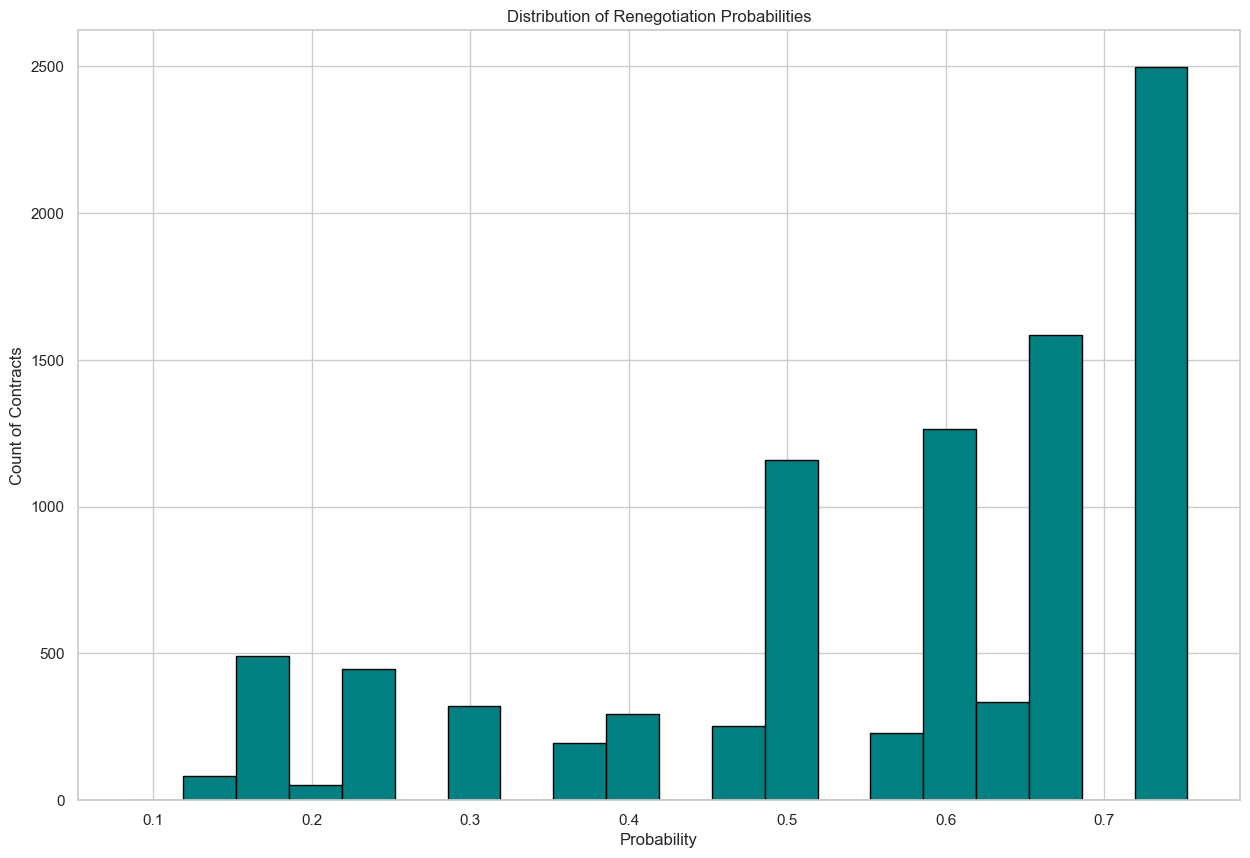

In [62]:
print("--- Label Distribution ---")
print(df_final_no_spend['target_renegotiate'].value_counts(normalize=True))

# Also check the spread of probabilities
import matplotlib.pyplot as plt
df_final_no_spend['renegotiation_prob'].hist(bins=20, color='teal', edgecolor='black')
plt.title("Distribution of Renegotiation Probabilities")
plt.xlabel("Probability")
plt.ylabel("Count of Contracts")
plt.show()

# XGBoost

/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_43312/3905358675.py:8: DtypeWarning: Columns (0: terminated, 1: supplier_number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv")


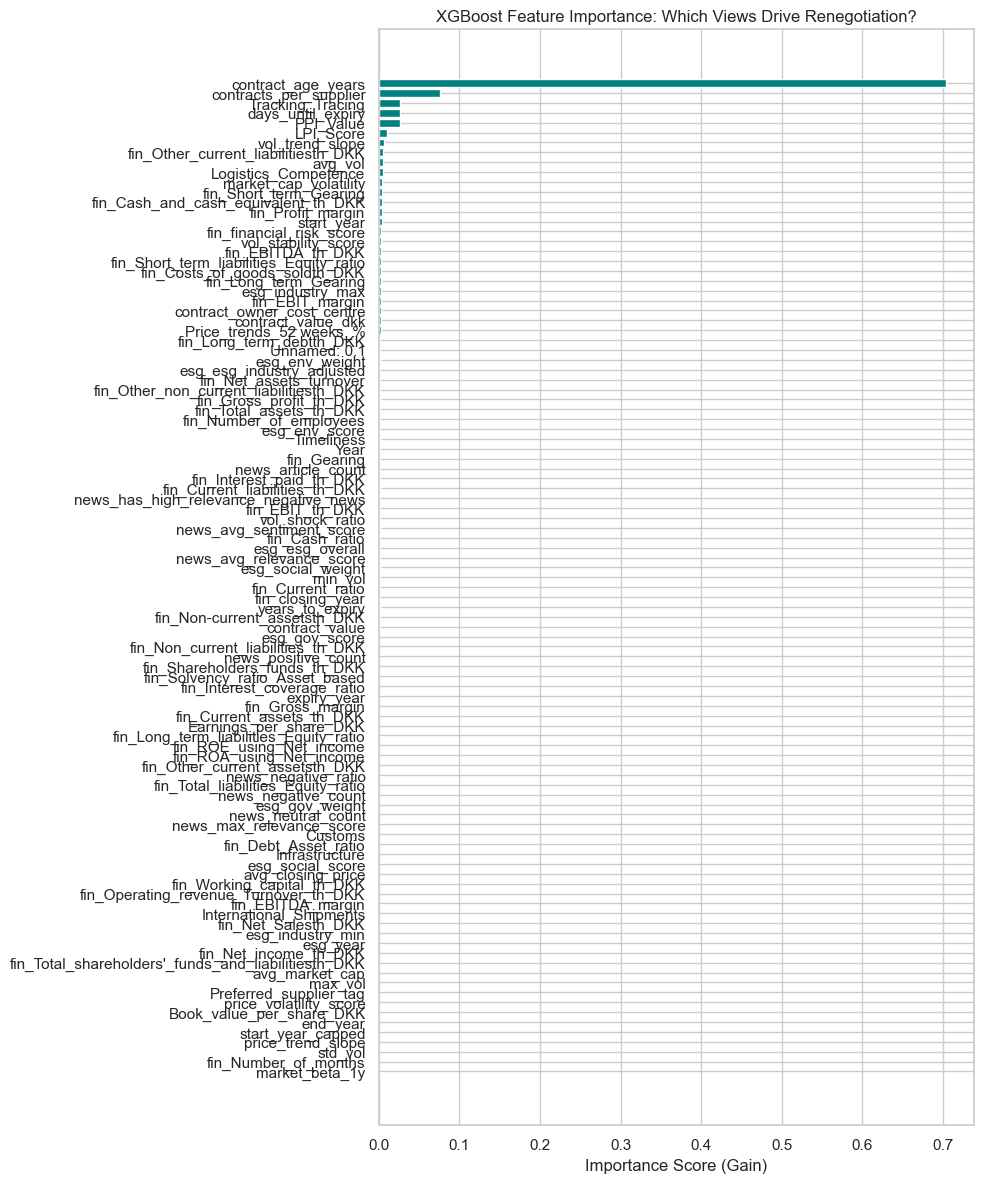

Suggested for elimination (Importance < 0.001):
['market_beta_1y', 'fin_Number_of_months', 'std_vol', 'price_trend_slope', 'start_year_capped', 'end_year', 'Book_value_per_share_DKK', 'price_volatility_score', 'Preferred_supplier_tag', 'max_vol', 'avg_market_cap', "fin_Total_shareholders'_funds_and_liabilitiesth_DKK", 'fin_Net_income_th_DKK', 'esg_year', 'esg_industry_min', 'fin_Net_Salesth_DKK', 'International_Shipments', 'fin_EBITDA_margin', 'fin_Operating_revenue_Turnover_th_DKK', 'fin_Working_capital_th_DKK', 'avg_closing_price', 'esg_social_score', 'Infrastructure', 'fin_Debt_Asset_ratio', 'Customs', 'news_max_relevance_score', 'news_neutral_count', 'esg_gov_weight', 'news_negative_count', 'fin_Total_liabilities_Equity_ratio', 'news_negative_ratio', 'fin_Other_current_assetsth_DKK', 'fin_ROA_using_Net_income', 'fin_ROE_using_Net_income', 'fin_Long_term_liabilities_Equity_ratio', 'Earnings_per_share_DKK', 'fin_Current_assets_th_DKK', 'fin_Gross_margin', 'expiry_year', 'fin_Interest

In [63]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Load your labeled data
# Assuming you saved the output from the Snorkel step
df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv") 

# 2. Pre-calculate the 'Consolidation' helper if not already there
df['contracts_per_supplier'] = df.groupby('supplier_id')['contract_id'].transform('nunique')

# 3. Select Numeric Features from your 5 Views
# We exclude IDs, text, and the labels themselves
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_list = [
    'contract_id', 'supplier_id', 'observation_year', 'renegotiation_prob', 
    'target_renegotiate', 'Unnamed: 0', '_c0', 'contract_number', 'supplier_number'
]
X_features = [c for c in numeric_cols if c not in exclude_list]

# 4. Prepare X and y
# We use 'renegotiation_prob' as the target (Regression) because it contains 
# more information than the 0/1 hard label.
X = df[X_features]
y = df['renegotiation_prob']

# 5. Initialize and Train XGBoost Regressor
# We use a regressor since our target is a probability (0.0 to 1.0)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    importance_type='gain' # 'gain' is the most relevant for feature elimination
)

model.fit(X, y)

# 6. Extract and Plot Importance
importance_df = pd.DataFrame({
    'feature': X_features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True) # Ascending for the horizontal plot

# 7. Visualization
plt.figure(figsize=(10, 12))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.title("XGBoost Feature Importance: Which Views Drive Renegotiation?")
plt.xlabel("Importance Score (Gain)")
plt.tight_layout()
plt.show()

# 8. Identify the 'Junk' features for removal
low_importance_threshold = 0.001
junk_features = importance_df[importance_df['importance'] < low_importance_threshold]['feature'].tolist()
print(f"Suggested for elimination (Importance < {low_importance_threshold}):")
print(junk_features)